# 03. Análisis de centralidad

En este cuaderno se calcula la centralidad de intermediación del árbol de expansión mínima (MST) del anterior cuaderno (residuos que superar el percentil 95). Además, se cuantifica la diferencia entre el estado WT y I150A.

## 1) Centralidad de intermediación en la enzima WT

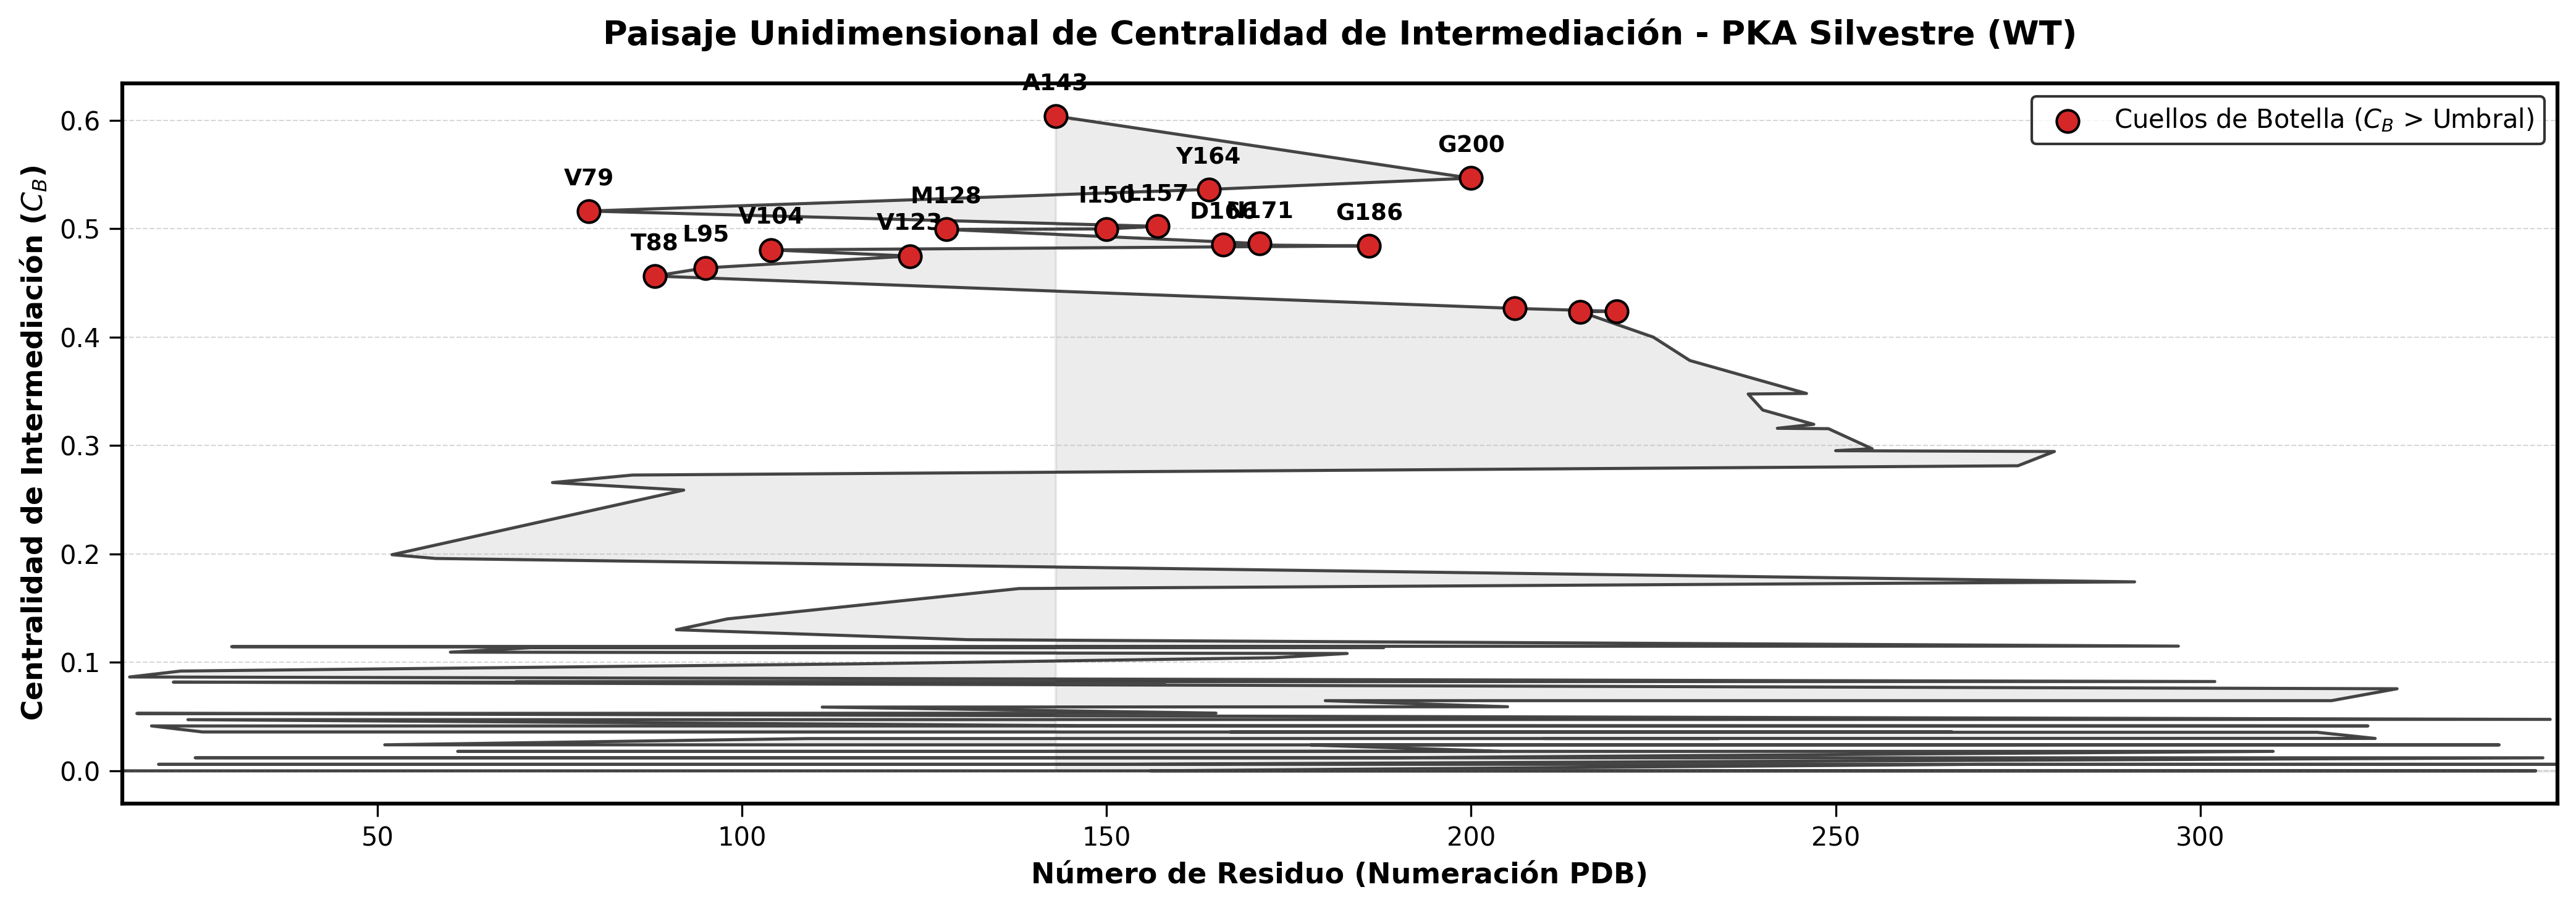

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Configuración de estilos gráficos de alta resolución para publicaciones científicas
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'figure.dpi': 300
})

# Rutas relativas de entrada para los perfiles de centralidad
centrality_wt_path = "../results/tables/Centrality_PKA_Allostery_WT.csv"
centrality_mut_path = "../results/tables/Centrality_PKA_Allostery_I150A.csv"

# Carga de datos de la condición silvestre
df_wt = pd.read_csv(centrality_wt_path)

# Generación del perfil 1D de Intermediación (WT)
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_wt["Residue_PDB"], df_wt["Betweenness_Centrality"], color="black", linewidth=1.2, alpha=0.7)
ax.fill_between(df_wt["Residue_PDB"], df_wt["Betweenness_Centrality"], color="gray", alpha=0.15)

# Aislamiento visual de los cuellos de botella biológicos
bottlenecks_wt = df_wt[df_wt["Is_Bottleneck"] == True]
ax.scatter(
    bottlenecks_wt["Residue_PDB"],
    bottlenecks_wt["Betweenness_Centrality"],
    color="#d62728",
    s=75,
    edgecolor="black",
    zorder=5,
    label="Cuellos de Botella ($C_B$ > Umbral)"
)

# Anotación de los residuos con máxima densidad de flujo (CB > 0.45)
for idx, row in bottlenecks_wt[bottlenecks_wt["Betweenness_Centrality"] > 0.45].iterrows():
    ax.annotate(
        f"{row['Amino_Acid']}{int(row['Residue_PDB'])}",
        (row['Residue_PDB'], row['Betweenness_Centrality']),
        textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold'
    )

ax.set_title("Paisaje Unidimensional de Centralidad de Intermediación - PKA Silvestre (WT)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Número de Residuo (Numeración PDB)", fontsize=11, fontweight="bold")
ax.set_ylabel("Centralidad de Intermediación ($C_B$)", fontsize=11, fontweight="bold")
ax.set_xlim(df_wt["Residue_PDB"].min(), df_wt["Residue_PDB"].max())
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc="upper right", frameon=True, edgecolor="black")

plt.tight_layout()
plt.show()

## 2) Tablas de centralidad entre WT y I150A

In [16]:
# Carga de la condición mutante
df_mut = pd.read_csv(centrality_mut_path)

# Filtrado y ordenación decreciente de los cuellos de botella para ambas variantes
bottlenecks_wt_table = df_wt[df_wt["Is_Bottleneck"] == True].sort_values(by="Betweenness_Centrality", ascending=False).reset_index(drop=True)
bottlenecks_mut_table = df_mut[df_mut["Is_Bottleneck"] == True].sort_values(by="Betweenness_Centrality", ascending=False).reset_index(drop=True)

# Renderizado de la tabla de la condición Silvestre (WT)
display(HTML("<h3>Cuellos de Botella Identificados - Condición Silvestre (WT)</h3>"))
display(bottlenecks_wt_table[["Residue_PDB", "Amino_Acid", "Betweenness_Centrality"]].style.format({
    "Betweenness_Centrality": "{:.4f}"
}).set_properties(**{'text-align': 'center'}).hide(axis="index"))

print("\n" + "-"*50 + "\n") # Separador estructural

# Renderizado de la tabla de la condición Mutante (I150A)
display(HTML("<h3>Cuellos de Botella Identificados - Variante Inactivadora (I150A)</h3>"))
display(bottlenecks_mut_table[["Residue_PDB", "Amino_Acid", "Betweenness_Centrality"]].style.format({
    "Betweenness_Centrality": "{:.4f}"
}).set_properties(**{'text-align': 'center'}).hide(axis="index"))

Residue_PDB,Amino_Acid,Betweenness_Centrality
143,A,0.6038
200,G,0.5465
164,Y,0.5361
79,V,0.5162
157,L,0.5021
150,I,0.4997
128,M,0.4993
171,N,0.4862
166,D,0.4851
186,G,0.4840



--------------------------------------------------



Residue_PDB,Amino_Acid,Betweenness_Centrality
200,G,0.5880
143,A,0.5666
164,Y,0.5430
79,V,0.5162
157,L,0.5044
150,A,0.5012
128,M,0.4993
171,N,0.4974
166,D,0.4969
186,G,0.4963


## 3) Espectro del recableado alostérico ($\Delta C_B$)

<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
C:\Users\usuario\AppData\Local\Temp\ipykernel_3512\180019270.py:36: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("($\Delta C_B$)", fontsize=12, fontweight="bold", labelpad=10)


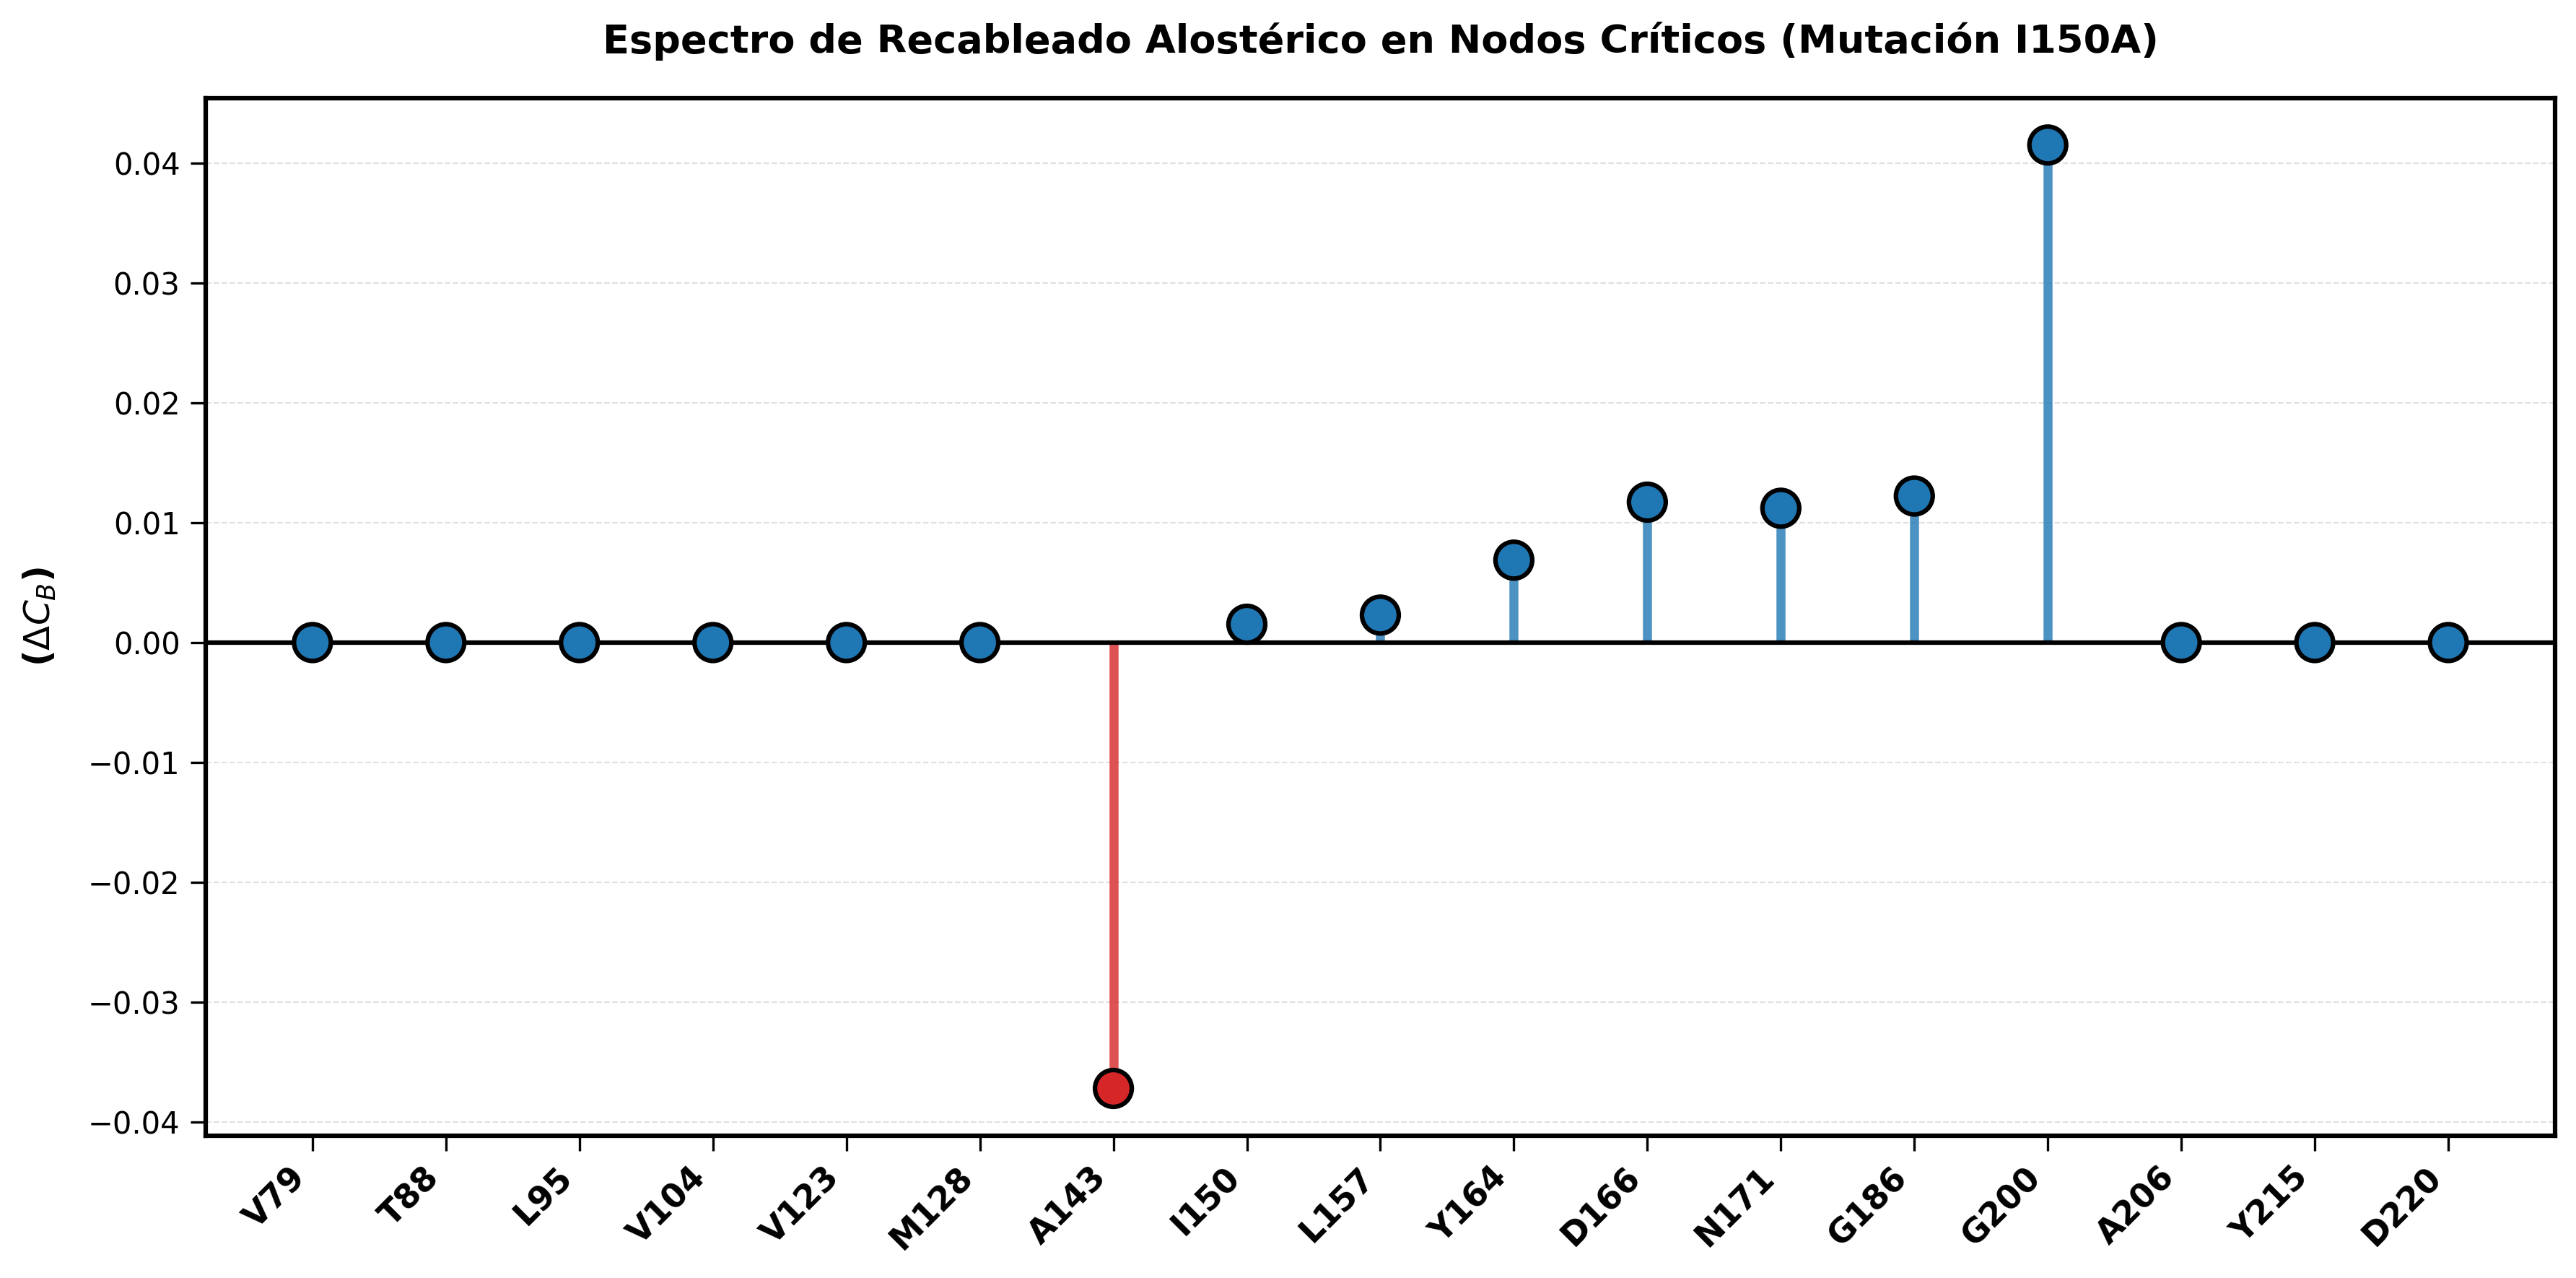

In [17]:
# Fusionar tablas usando el Residue_PDB como clave
df_merged = pd.merge(df_wt, df_mut, on="Residue_PDB", suffixes=('_WT', '_I150A'))

# FILTRO BIOFÍSICO CRÍTICO: Retener solo los residuos que fueron cuellos de botella en al menos un estado
df_filtered = df_merged[(df_merged['Is_Bottleneck_WT'] == True) | (df_merged['Is_Bottleneck_I150A'] == True)].copy()

# Calcular el Delta de Centralidad (Mutante - WT)
df_filtered['Delta_BC'] = df_filtered['Betweenness_Centrality_I150A'] - df_filtered['Betweenness_Centrality_WT']

# Ordenar los residuos físicamente por la secuencia primaria (Residue_PDB)
df_filtered = df_filtered.sort_values('Residue_PDB')

# Crear etiquetas biológicas legibles combinadas (ej: "A143", "G200")
df_filtered['Label'] = df_filtered['Amino_Acid_WT'] + df_filtered['Residue_PDB'].astype(str)

# Configurar las dimensiones y tipografía de la figura diferencial
plt.figure(figsize=(12, 6))
x = np.arange(len(df_filtered))
y = df_filtered['Delta_BC'].values

# Definición de la paleta divergente: Rojo para pérdida de flujo informacional, Azul para ganancia
colors = ['#d62728' if val < 0 else '#1f77b4' for val in y]

# Dibujar el Lollipop Plot
# 1. Líneas verticales de tensión topológica
plt.vlines(x=x, ymin=0, ymax=y, color=colors, alpha=0.8, linewidth=3)
# 2. Cabezas de asignación cuantitativa
plt.scatter(x, y, color=colors, s=150, zorder=3, edgecolors='black', linewidths=1.5)

# Trazado de la línea base de perturbación nula
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

# Ajuste estético fino de los ejes y rejillas
plt.xticks(x, df_filtered['Label'], rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.title("Espectro de Recableado Alostérico en Nodos Críticos (Mutación I150A)", fontsize=13, fontweight="bold", pad=15)
plt.ylabel("($\Delta C_B$)", fontsize=12, fontweight="bold", labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()